In [ ]:
from typing import Callable, ClassVar, Literal

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from clawpack import pyclaw, riemann
from context_flux_no.nn.utils import num_parameters
from context_flux_no.simulations.pdesolve import pdesolve_pyclaw
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_enable_x64", True)

In [2]:
class TruncatedFourier1D(eqx.Module):
    an: Float[Array, " K"]
    bn: Float[Array, " K"]
    a0: Float[Array, ""] = eqx.field(default_factory=lambda: jnp.array(0.0))
    L: float = eqx.field(static=True, default=1.0)

    def __call__(self, x: Float[Array, " *shape"]):
        kx: Float[Array, "*shape K"] = jnp.expand_dims(x, axis=-1) * self.wavenumbers
        cos_kx, sin_kx = jnp.cos(kx), jnp.sin(kx)
        return self.a0 + jnp.mean(
            self.an * cos_kx + self.bn * sin_kx, axis=-1
        ) / jnp.sqrt(2)

    @property
    def num_modes(self) -> int:
        return len(self.an)

    @property
    def wavenumbers(self) -> Float[Array, " K"]:
        return jnp.arange(1, self.num_modes + 1) * 2 * jnp.pi / self.L

    @classmethod
    def with_uniform_rand_coeffs(
        cls,
        num_modes: int,
        L: float = 1.0,
        coeff_range: tuple[float, float] = (1, 1),
        offset_range: tuple[float, float] | None = None,
        *,
        key: PRNGKeyArray = jax.random.PRNGKey(0),
    ):
        key_coeff, key_offset = jax.random.split(key, 2)
        an_bn = jax.random.uniform(
            key_coeff,
            shape=(2, num_modes),
            minval=coeff_range[0],
            maxval=coeff_range[1],
        )
        if offset_range is None:
            a0 = jnp.array(0.0)
        else:
            a0 = jax.random.uniform(
                key_offset, minval=offset_range[0], maxval=offset_range[1]
            )
        return cls(*an_bn, a0, L)

INFO:2025-09-10 18:29:18,540:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-09-10 18:29:18,540 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


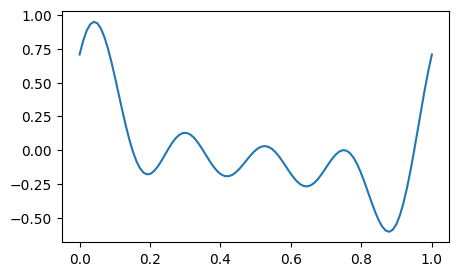

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [4]:
class Burgers1D(eqx.Module):
    n_dim: ClassVar[int] = 1
    n_eqns: ClassVar[int] = 1
    nu: float = eqx.field(static=True, default=0.0)
    entropy_fix: bool = eqx.field(static=True, default=True)

    def solve_pyclaw(
        self,
        ic_factory: Callable[[Float[np.ndarray, " Nx"]], Float[np.ndarray, " Nx"]],
        x_span: tuple[float, float],
        Nx: int,
        t_span: tuple[float, float],
        Nt: int,
        bc: Literal["periodic"],
    ) -> tuple[
        Float[np.ndarray, "time dim x_grid"],
        Float[np.ndarray, " time"],
        Float[np.ndarray, " x_grid"],
    ]:
        solver = pyclaw.ClawSolver1D(riemann.burgers_1D)
        solver.limiters = pyclaw.limiters.tvd.vanleer

        problem_data = {"efix": self.entropy_fix}
        return pdesolve_pyclaw(
            solver, problem_data, ic_factory, x_span, Nx, t_span, Nt, bc
        )


In [5]:
burgers = Burgers1D()
u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
u, t, x = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 1024, (0.0, 6.0), 1000, "periodic")

2025-09-10 18:29:23,206 INFO CLAW: Solution 0 computed for time t=0.000000
2025-09-10 18:29:23,208 INFO CLAW: Solution 1 computed for time t=0.006000
2025-09-10 18:29:23,209 INFO CLAW: Solution 2 computed for time t=0.012000
2025-09-10 18:29:23,211 INFO CLAW: Solution 3 computed for time t=0.018000
2025-09-10 18:29:23,213 INFO CLAW: Solution 4 computed for time t=0.024000
2025-09-10 18:29:23,214 INFO CLAW: Solution 5 computed for time t=0.030000
2025-09-10 18:29:23,216 INFO CLAW: Solution 6 computed for time t=0.036000
2025-09-10 18:29:23,217 INFO CLAW: Solution 7 computed for time t=0.042000
2025-09-10 18:29:23,219 INFO CLAW: Solution 8 computed for time t=0.048000
2025-09-10 18:29:23,220 INFO CLAW: Solution 9 computed for time t=0.054000
2025-09-10 18:29:23,222 INFO CLAW: Solution 10 computed for time t=0.060000
2025-09-10 18:29:23,223 INFO CLAW: Solution 11 computed for time t=0.066000
2025-09-10 18:29:23,225 INFO CLAW: Solution 12 computed for time t=0.072000
2025-09-10 18:29:23,22

In [6]:
import logging


logger = logging.getLogger("pyclaw")
logger.__dict__

{'filters': [],
 'name': 'pyclaw',
 'level': 20,
 'parent': <RootLogger root (INFO)>,
 'propagate': 1,
 'handlers': [<FileHandler /home/jhko725/projects/CONTEXT_FLUX_NO/notebooks/data_generation/pyclaw.log (NOTSET)>,
  <StreamHandler stdout (INFO)>],
 'disabled': 0,
 '_cache': {},
 'manager': <logging.Manager at 0x1488c1fd29c0>}

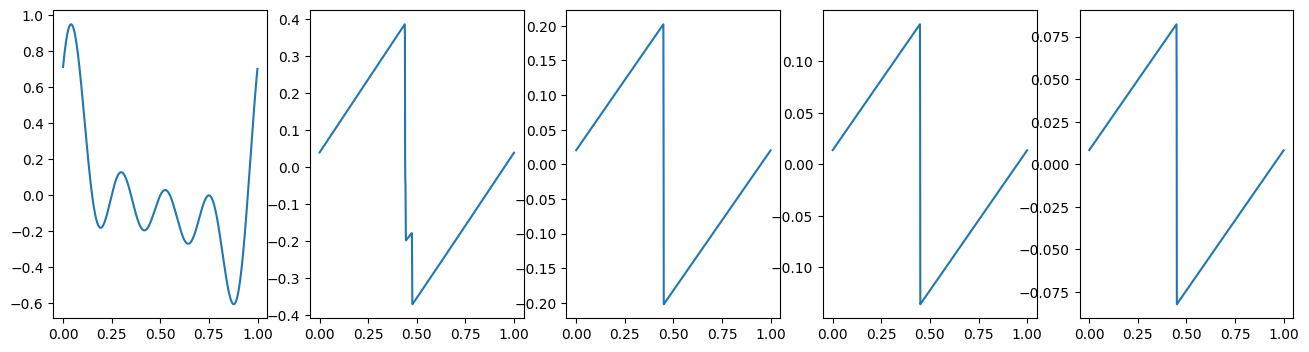

In [7]:
t_vals = (0, 200, 400, 600, 1000)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(x, u[t_i, 0])

In [ ]:
data_array = xr.DataArray(
    np.expand_dims(u, axis=0),
    coords={
        "t": t,
        "x": x,
        "dim": [
            "u",
        ],
        "nu": ("sample", [0.0]),
    },
    dims=["sample", "t", "dim", "x"],
)

In [9]:
data_array

<xarray.DataArray (sample: 1, t: 1001, dim: 1, x: 1024)> Size: 8MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]]], shape=(1, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.006 0.012 0.018 ... 5.982 5.988 5.994 6.0
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

In [10]:
xr.concat((data_array, data_array), "sample")

<xarray.DataArray (sample: 2, t: 1001, dim: 1, x: 1024)> Size: 16MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]],


       [[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]]], shape=(2, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.006 0.012 0.018 ... 5.982 5.988 5.994 6.0
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 16B 0.0 0.0
Dimensions without coordinates: sample

In [11]:
data_array.coords["nu"].dims

('sample',)

In [12]:
from context_flux_no.models.fluxfno import FluxFNO1D


model = FluxFNO1D(
    data_dim=1,
    lift_dim=64,
    depth=4,
    frequency_modes=8,
    stencil_size=2,
    key=jax.random.key(0),
)

u = jnp.asarray(data_array[0, 0])
u.shape

(1, 1024)

In [13]:
u_out = model(u, 6.0 / 1000, 1.0 / 1024)

2025-09-10 18:29:37.782885: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-10 18:29:38.949871: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.167130155s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

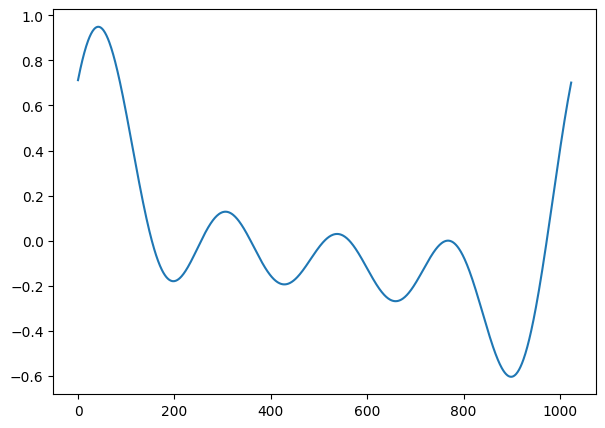

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(u_out[0])

In [25]:
num_parameters(model)

165313

In [ ]:
# model = FNO1D(
#     data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
# )


TypeError: FNO1D.__init__() got an unexpected keyword argument 'data_dim'

In [13]:
out = fno(sol[0])

2025-07-29 01:36:37.117089: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-29 01:36:40.975288: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.858323399s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

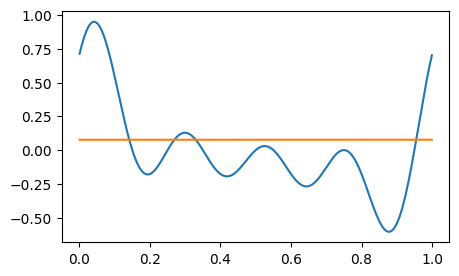

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [15]:
sol[1:501].shape

(500, 1, 1024)

In [14]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model, in_axes=(0, None, None))(
        u0, 6.0 / 1000, 1.0 / 1024
    )
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [15]:
sol = jnp.asarray(data_array[0])
sol.shape

(1001, 1, 1024)

In [16]:
max_epochs = 1000
loss_history = []
for i in range(max_epochs):
    model, opt_state, loss = make_step(model, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.0005161681187226657
Epoch = 1: Loss = 0.0005158406756265919
Epoch = 2: Loss = 0.0005154977784066621
Epoch = 3: Loss = 0.000515122003697004
Epoch = 4: Loss = 0.0005146923125998957
Epoch = 5: Loss = 0.0005141822013877835
Epoch = 6: Loss = 0.0005135569455099677
Epoch = 7: Loss = 0.0005127694222764438
Epoch = 8: Loss = 0.0005117537665198371
Epoch = 9: Loss = 0.0005104156859939352
Epoch = 10: Loss = 0.000508617560278349
Epoch = 11: Loss = 0.000506155460126932
Epoch = 12: Loss = 0.0005027239956069132
Epoch = 13: Loss = 0.0004978638331798654
Epoch = 14: Loss = 0.0004908871757632568
Epoch = 15: Loss = 0.000480781879565681
Epoch = 16: Loss = 0.0004661123852537025
Epoch = 17: Loss = 0.000444979654092726
Epoch = 18: Loss = 0.0004152048530624698
Epoch = 19: Loss = 0.00037514740788685184
Epoch = 20: Loss = 0.000326232207526968
Epoch = 21: Loss = 0.000280084890444387
Epoch = 22: Loss = 0.0002717303952599079
Epoch = 23: Loss = 0.0002992213077430029
Epoch = 24: Loss = 0.00028470263

Text(0, 0.5, 'Train loss')

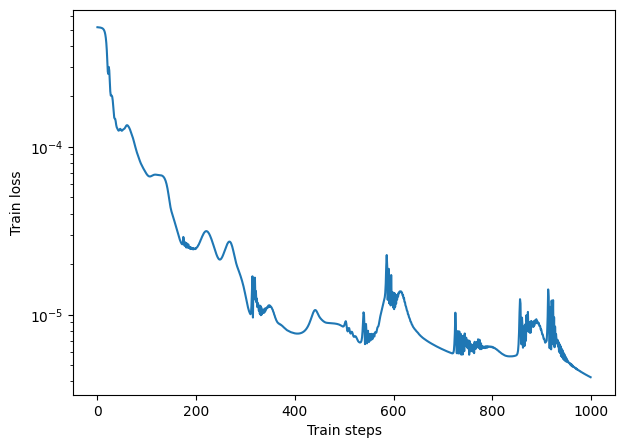

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Train steps")
ax.set_ylabel("Train loss")

In [27]:
float(data_array.t[1] - data_array.t[0])

0.006

Text(0, 0.5, '$u_{pred}-u_{data}$')

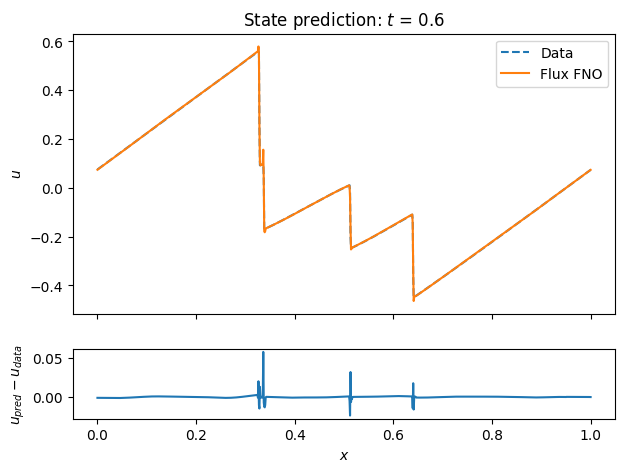

In [34]:
time_idx = 100
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=(4, 1))
u_data = sol[time_idx + 1][0]
u_pred = model(sol[time_idx], 6.0 / 1000, 1.0 / 1024)[0]
axes[0].plot(data_array.x, u_data, "--", label="Data")
axes[0].plot(data_array.x, u_pred, label="Flux FNO")
axes[0].legend()

axes[0].set_ylabel("$u$")
axes[0].set_title(
    f"State prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)
axes[1].plot(data_array.x, u_pred - u_data)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u_{pred}-u_{data}$")

Text(0.5, 1.0, 'Flux prediction: $t$ = 0.6')

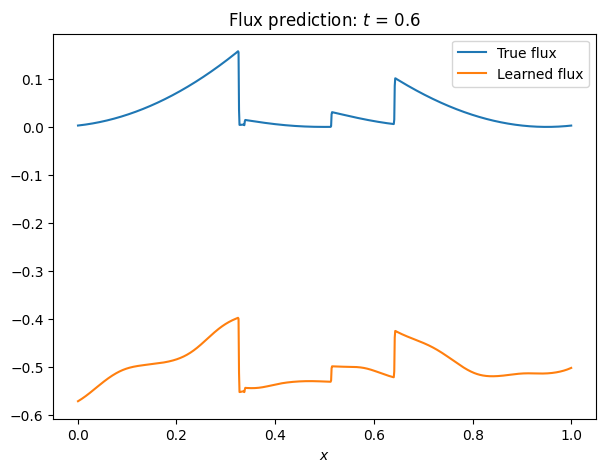

In [39]:
time_idx = 100
f_pred = model.physical_flux(sol[time_idx])
f_true = 0.5 * sol[time_idx] ** 2
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(data_array.x, f_true[0], label="True flux")
ax.plot(data_array.x, f_pred[0], label="Learned flux")
ax.legend()
ax.set_xlabel("$x$")
ax.set_title(
    f"Flux prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)